In [3]:
import numpy as np
import pandas as pd
import multiprocessing as mp
from inspect import signature
from matplotlib import pyplot as plt
from dacbench.logger import Logger, log2dataframe, load_logs
import seaborn as sns
import glob
# from plotting import plot_performance_over_time, plot_final_performance_comparison, plot_improvement_probability, plot_configuration_footprint, plot_hp_importance, plot_deepcave

/home/micha/anaconda3/envs/PFDAC/lib/python3.10/site-packages/dacbench/envs/__init__.py:35: UserWarning: CMA-ES Benchmark not installed. If you want to use this benchmark, please follow the installation guide.
  warnings.warn(  # noqa: B028
/home/micha/anaconda3/envs/PFDAC/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DACBench Gym registration failed - make sure you have all dependencies installed and their instance sets in the right path!


/home/micha/anaconda3/envs/PFDAC/lib/python3.10/site-packages/dacbench/benchmarks/__init__.py:26: UserWarning: CMA-ES Benchmark not installed. If you want to use this benchmark, please follow the installation guide.
  warnings.warn(  # noqa: B028


In [14]:
def toDataFrame(glob_path, col_name, col_index):
    d =  [log2dataframe(load_logs(path)) for path in glob.glob(glob_path)]

    df = pd.DataFrame([s[col_name][col_index] for s in d]).transpose()
    df['epoch'] = df.index + 1
    df = df.melt(id_vars=['epoch'])

    return df

def toChunkedDataFrame(glob_path, col_name, col_index, chunk_size):
    d =  [log2dataframe(load_logs(path)) for path in glob.glob(glob_path)]

    df = pd.DataFrame([s[col_name][col_index] for s in d]).transpose()

    result_df = pd.DataFrame()
    for col in df.columns:
        reshaped_data = df[col].values.reshape(-1, chunk_size)
        result_df[col] = reshaped_data.mean(axis=1)

    result_df.reset_index()

    result_df['epoch'] = result_df.index + 1
    result_df = result_df.melt(id_vars=['epoch'])

    return result_df

sns.set(rc={"figure.dpi":100, 'savefig.dpi':100})
sns.set_style('whitegrid')
palette = sns.color_palette("colorblind")
palette = sns.color_palette([palette[0], palette[2], palette[1], palette[3], palette[4], palette[5]])
sns.set_palette(palette)

Text(0, 0.5, 'Training Loss')

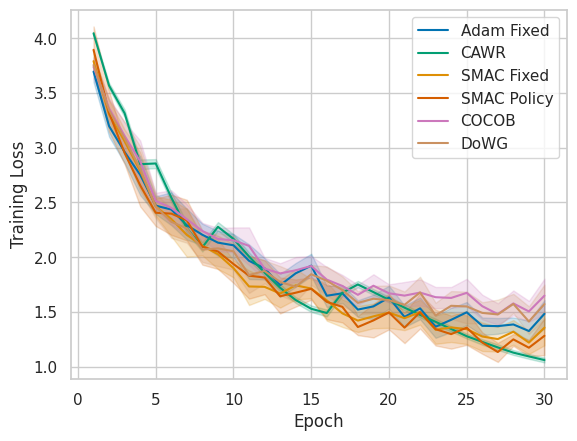

In [16]:

cocob_tl = toDataFrame('./results_cluster/results/COCOB_cifar100/*/CustomTrackingWrapper.jsonl', 'training_losses', 3)
adam_fixed_tl = toDataFrame('./results_cluster/results/Adam_fixed_cifar100/*/CustomTrackingWrapper.jsonl', 'training_losses', 3)
dowg_tl = toDataFrame('./results_cluster/results/DoWG_cifar100/*/CustomTrackingWrapper.jsonl', 'training_losses', 3)
smac_fixed_tl = toDataFrame('./results_cluster/results/SMAC_fixed_cifar100/*/CustomTrackingWrapper.jsonl', 'training_losses', 3)
# smac_fixed_tl = smac_fixed_tl.loc[smac_fixed_tl['epoch'] <= 30]
smac_policy_tl = toDataFrame('./results_cluster/results/smacpolicy_cifar100/*/CustomTrackingWrapper.jsonl', 'training_losses', 3)
cawr_tl = toChunkedDataFrame('./results_cluster/results/CAWR_cifar100/*/CustomTrackingWrapper.jsonl', 'training_losses', 3, 625)

sns.lineplot(data=adam_fixed_tl, x='epoch', y='value', label='Adam Fixed')
sns.lineplot(data=cawr_tl, x='epoch', y='value', label='CAWR')
sns.lineplot(data=smac_fixed_tl, x='epoch', y='value', label='SMAC Fixed')
sns.lineplot(data=smac_policy_tl, x='epoch', y='value', label='SMAC Policy')
sns.lineplot(data=cocob_tl, x='epoch', y='value', label='COCOB')
sns.lineplot(data=dowg_tl, x='epoch', y='value', label='DoWG')
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
# plt.yscale('log')

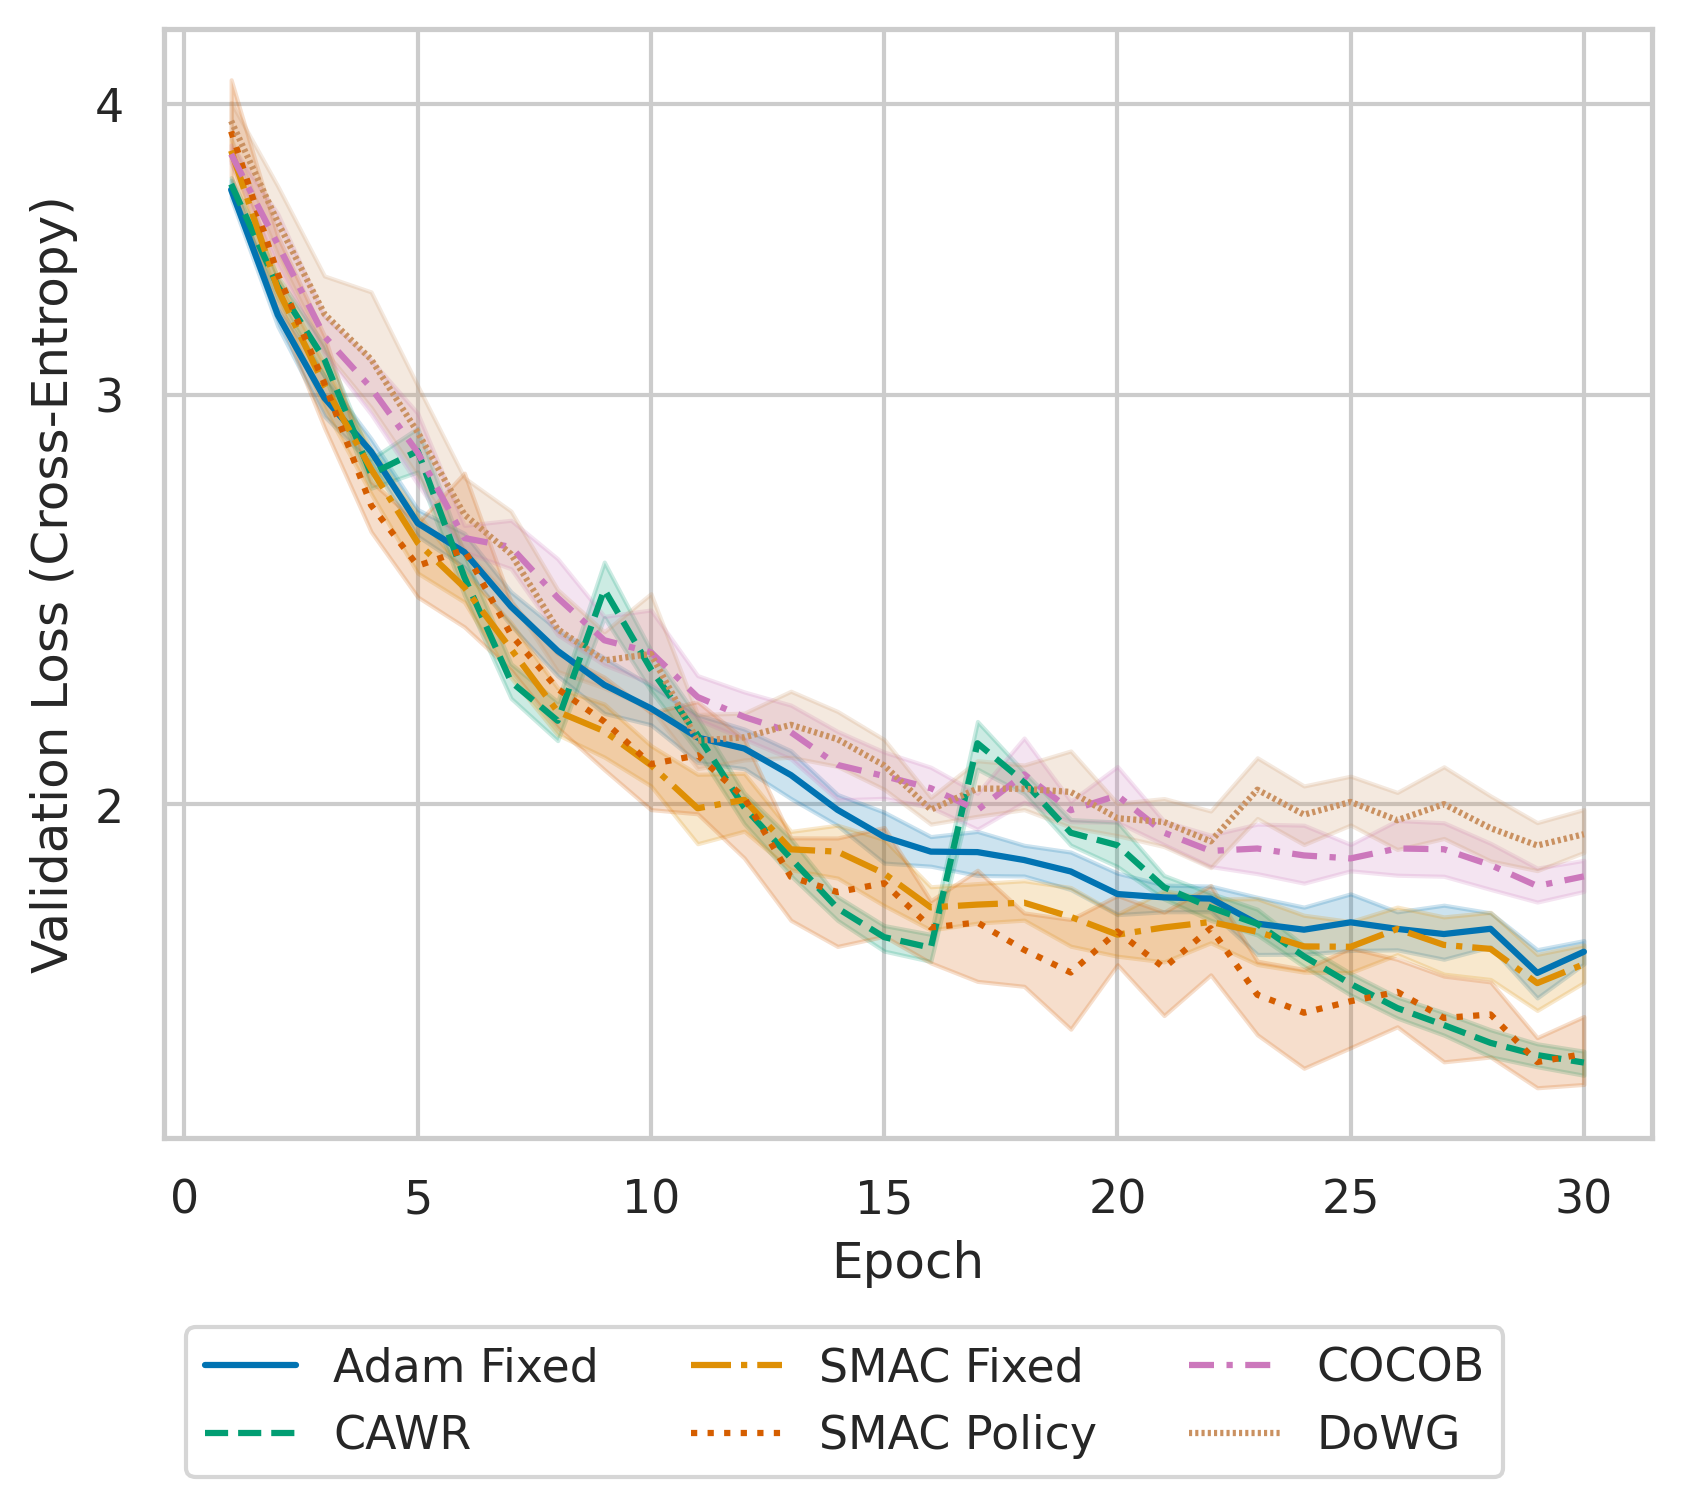

In [22]:

cocob_vl = toDataFrame('./results_cluster/results/COCOB_cifar100/*/CustomTrackingWrapper.jsonl', 'validation_losses', 5)
adam_fixed_vl = toDataFrame('./results_cluster/results/Adam_fixed_cifar100/*/CustomTrackingWrapper.jsonl', 'validation_losses', 5)
dowg_vl = toDataFrame('./results_cluster/results/DoWG_cifar100/*/CustomTrackingWrapper.jsonl', 'validation_losses', 5)
smac_fixed_vl = toDataFrame('./results_cluster/results/SMAC_fixed_cifar100/*/CustomTrackingWrapper.jsonl', 'validation_losses', 5)
# smac_fixed_vl= smac_fixed_vl.loc[smac_fixed_vl['epoch'] <= 30]
cawr_vl = toDataFrame('./results_cluster/results/CAWR_cifar100/*/CustomTrackingWrapper.jsonl', 'validation_losses', 5)
smac_policy_vl = toDataFrame('./results_cluster/results/smacpolicy_cifar100/*/CustomTrackingWrapper.jsonl', 'validation_losses', 5)
# cawr_vl = cawr_vl.loc[cawr_vl['epoch'] <= 50]


p = sns.lineplot(data=adam_fixed_vl, x='epoch', y='value', label='Adam Fixed', linestyle='solid')
sns.lineplot(data=cawr_vl, x='epoch', y='value', label='CAWR', linestyle="dashed")
sns.lineplot(data=smac_fixed_vl, x='epoch', y='value', label='SMAC Fixed', linestyle='dashdot')
sns.lineplot(data=smac_policy_vl, x='epoch', y='value', label='SMAC Policy', linestyle='dotted')
sns.lineplot(data=cocob_vl, x='epoch', y='value', label='COCOB', dashes=(4,2,1,2))
sns.lineplot(data=dowg_vl, x='epoch', y='value', label='DoWG', dashes=(0.5, 0.5))


plt.xlabel('Epoch')
plt.ylabel('Validation Loss (Cross-Entropy)')
plt.yscale('log')
plt.yticks([2, 3, 4], ["2", "3", "4"])
sns.move_legend(p, 'upper left', bbox_to_anchor=(0, -0.15), ncol=3)

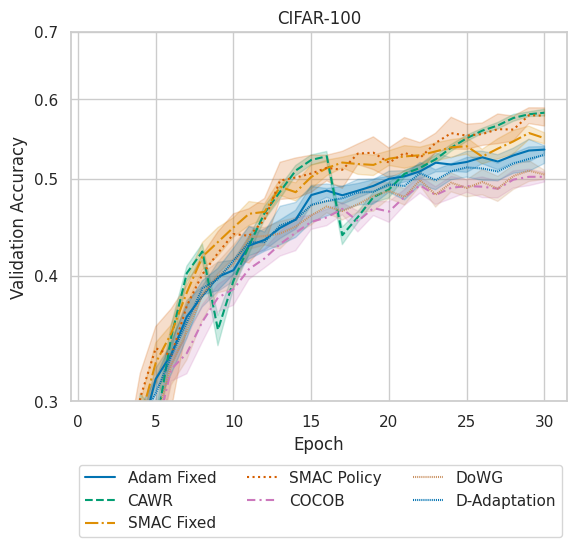

In [ ]:

cocob_va = toDataFrame('../results_cluster/results/COCOB_cifar100/*/CustomTrackingWrapper.jsonl', 'validation_accuracies', 6)
adam_fixed_va = toDataFrame('../results_cluster/results/Adam_fixed_cifar100/*/CustomTrackingWrapper.jsonl', 'validation_accuracies', 6)
dowg_va = toDataFrame('../results_cluster/results/DoWG_cifar100/*/CustomTrackingWrapper.jsonl', 'validation_accuracies', 6)
smac_fixed_va = toDataFrame('../results_cluster/results/SMAC_fixed_cifar100/*/CustomTrackingWrapper.jsonl', 'validation_accuracies', 6)
smac_policy_va = toDataFrame('../results_cluster/results/smacpolicy_cifar100/*/CustomTrackingWrapper.jsonl', 'validation_accuracies', 6)
dadaptation_va = toDataFrame('../results_cluster/results/dadaptation_cifar100/*/CustomTrackingWrapper.jsonl', 'validation_accuracies', 6)
cawr_va = toDataFrame('../results_cluster/results/CAWR_cifar100/*/CustomTrackingWrapper.jsonl', 'validation_accuracies', 6)
cawr_va = cawr_va.loc[cawr_va['epoch'] <= 50]

p = sns.lineplot(data=adam_fixed_va, x='epoch', y='value', label='Adam Fixed', linestyle='solid')
sns.lineplot(data=cawr_va, x='epoch', y='value', label='CAWR', linestyle="dashed")
# sns.lineplot(data=smac_fixed_va, x='epoch', y='value', label='SMAC Fixed', linestyle='dashdot')
# sns.lineplot(data=smac_policy_va, x='epoch', y='value', label='SMAC Policy', linestyle='dotted')
sns.lineplot(data=cocob_va, x='epoch', y='value', label='COCOB', dashes=(4,2,1,2))
# sns.lineplot(data=dowg_va, x='epoch', y='value', label='DoWG', dashes=(0.5, 0.5))
sns.lineplot(data=dadaptation_va, x='epoch', y='value', label='D-Adaptation', dashes=(0.5, 0.5))

plt.title('CIFAR-100')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.yscale('log')
plt.ylim(0.3, 0.7)
plt.yticks([0.3, 0.4, 0.5, 0.6, 0.7], ["0.3", "0.4", "0.5", "0.6", "0.7"])
sns.move_legend(p, 'upper left', bbox_to_anchor=(0, -0.15), ncol=3)

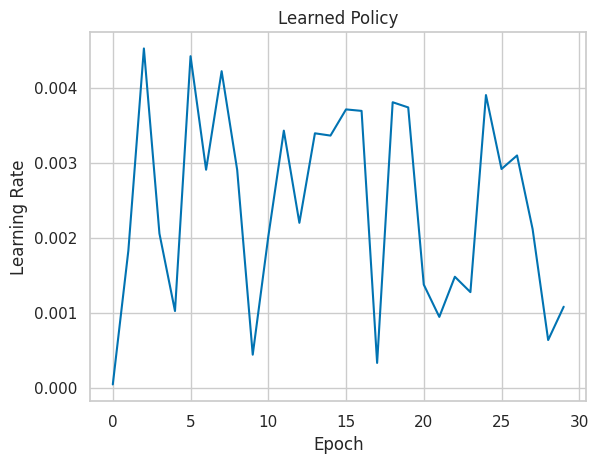

In [9]:

# cocob_elr = toDataFrame('./results_cluster/results_thesis/SMAC_/*/CustomTrackingWrapper.jsonl', 'effective_lrs', 9)
values = [
    4.4226624091829525e-05,  # x0
    0.0018259836030591705,   # x1
    0.004520514929569025,    # x2
    0.0020542166979302325,   # x3
    0.00102251658420928,     # x4
    0.004417327795600383,    # x5
    0.0029049324490012145,   # x6
    0.0042174067131199615,   # x7
    0.0029021225182663357,   # x8
    0.00044086840621090527,  # x9
    0.002012776015668199,    # x10
    0.003425364561001644,    # x11
    0.0021971587416902915,   # x12
    0.0033900583913646283,   # x13
    0.003359650478316156,    # x14
    0.003708422283940095,    # x15
    0.0036887584500677494,   # x16
    0.0003309513143645408,   # x17
    0.00380401228152878,     # x18
    0.0037347875889513194,   # x19
    0.0013742436693323576,   # x20
    0.000944209974896288,    # x21
    0.0014788779691239915,   # x22
    0.0012741455778310707,   # x23
    0.003899430263905116,    # x24
    0.002914297194565874,    # x25
    0.003094888546639704,    # x26
    0.0021141600198081585,   # x27
    0.0006360404063698884,   # x28
    0.0010797727478152608    # x29
]

sns.set(rc={"figure.dpi":100, 'savefig.dpi':100})
sns.set_style('whitegrid')
palette = sns.color_palette("colorblind")
palette = sns.color_palette([palette[0], palette[2], palette[1], palette[3], palette[4], palette[5]])
sns.set_palette(palette)

plt.plot(values)
plt.xlabel('Epoch')
plt.ylabel('Learning Rate')
plt.title('Learned Policy')
plt.savefig('filename.png', dpi=300)